In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import pearsonr

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('student-mat.csv', sep = ';')

In [3]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [4]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [5]:
quant_df = df[['age','studytime','failures',
               'absences','G1','G2','G3']]
quant_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        395 non-null    int64
 1   studytime  395 non-null    int64
 2   failures   395 non-null    int64
 3   absences   395 non-null    int64
 4   G1         395 non-null    int64
 5   G2         395 non-null    int64
 6   G3         395 non-null    int64
dtypes: int64(7)
memory usage: 21.7 KB


In [6]:
quant_df.describe()

,age,studytime,failures,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.035443,0.334177,5.708861,10.908861,10.713924,10.415190
std,1.276043,0.839240,0.743651,8.003096,3.319195,3.761505,4.581443
min,15.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,1.000000,0.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,2.000000,0.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,2.000000,0.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,3.000000,75.000000,19.000000,19.000000,20.000000


In [7]:
quant_df.isnull().sum()

,0
age,0
studytime,0
failures,0
absences,0
G1,0
G2,0
G3,0


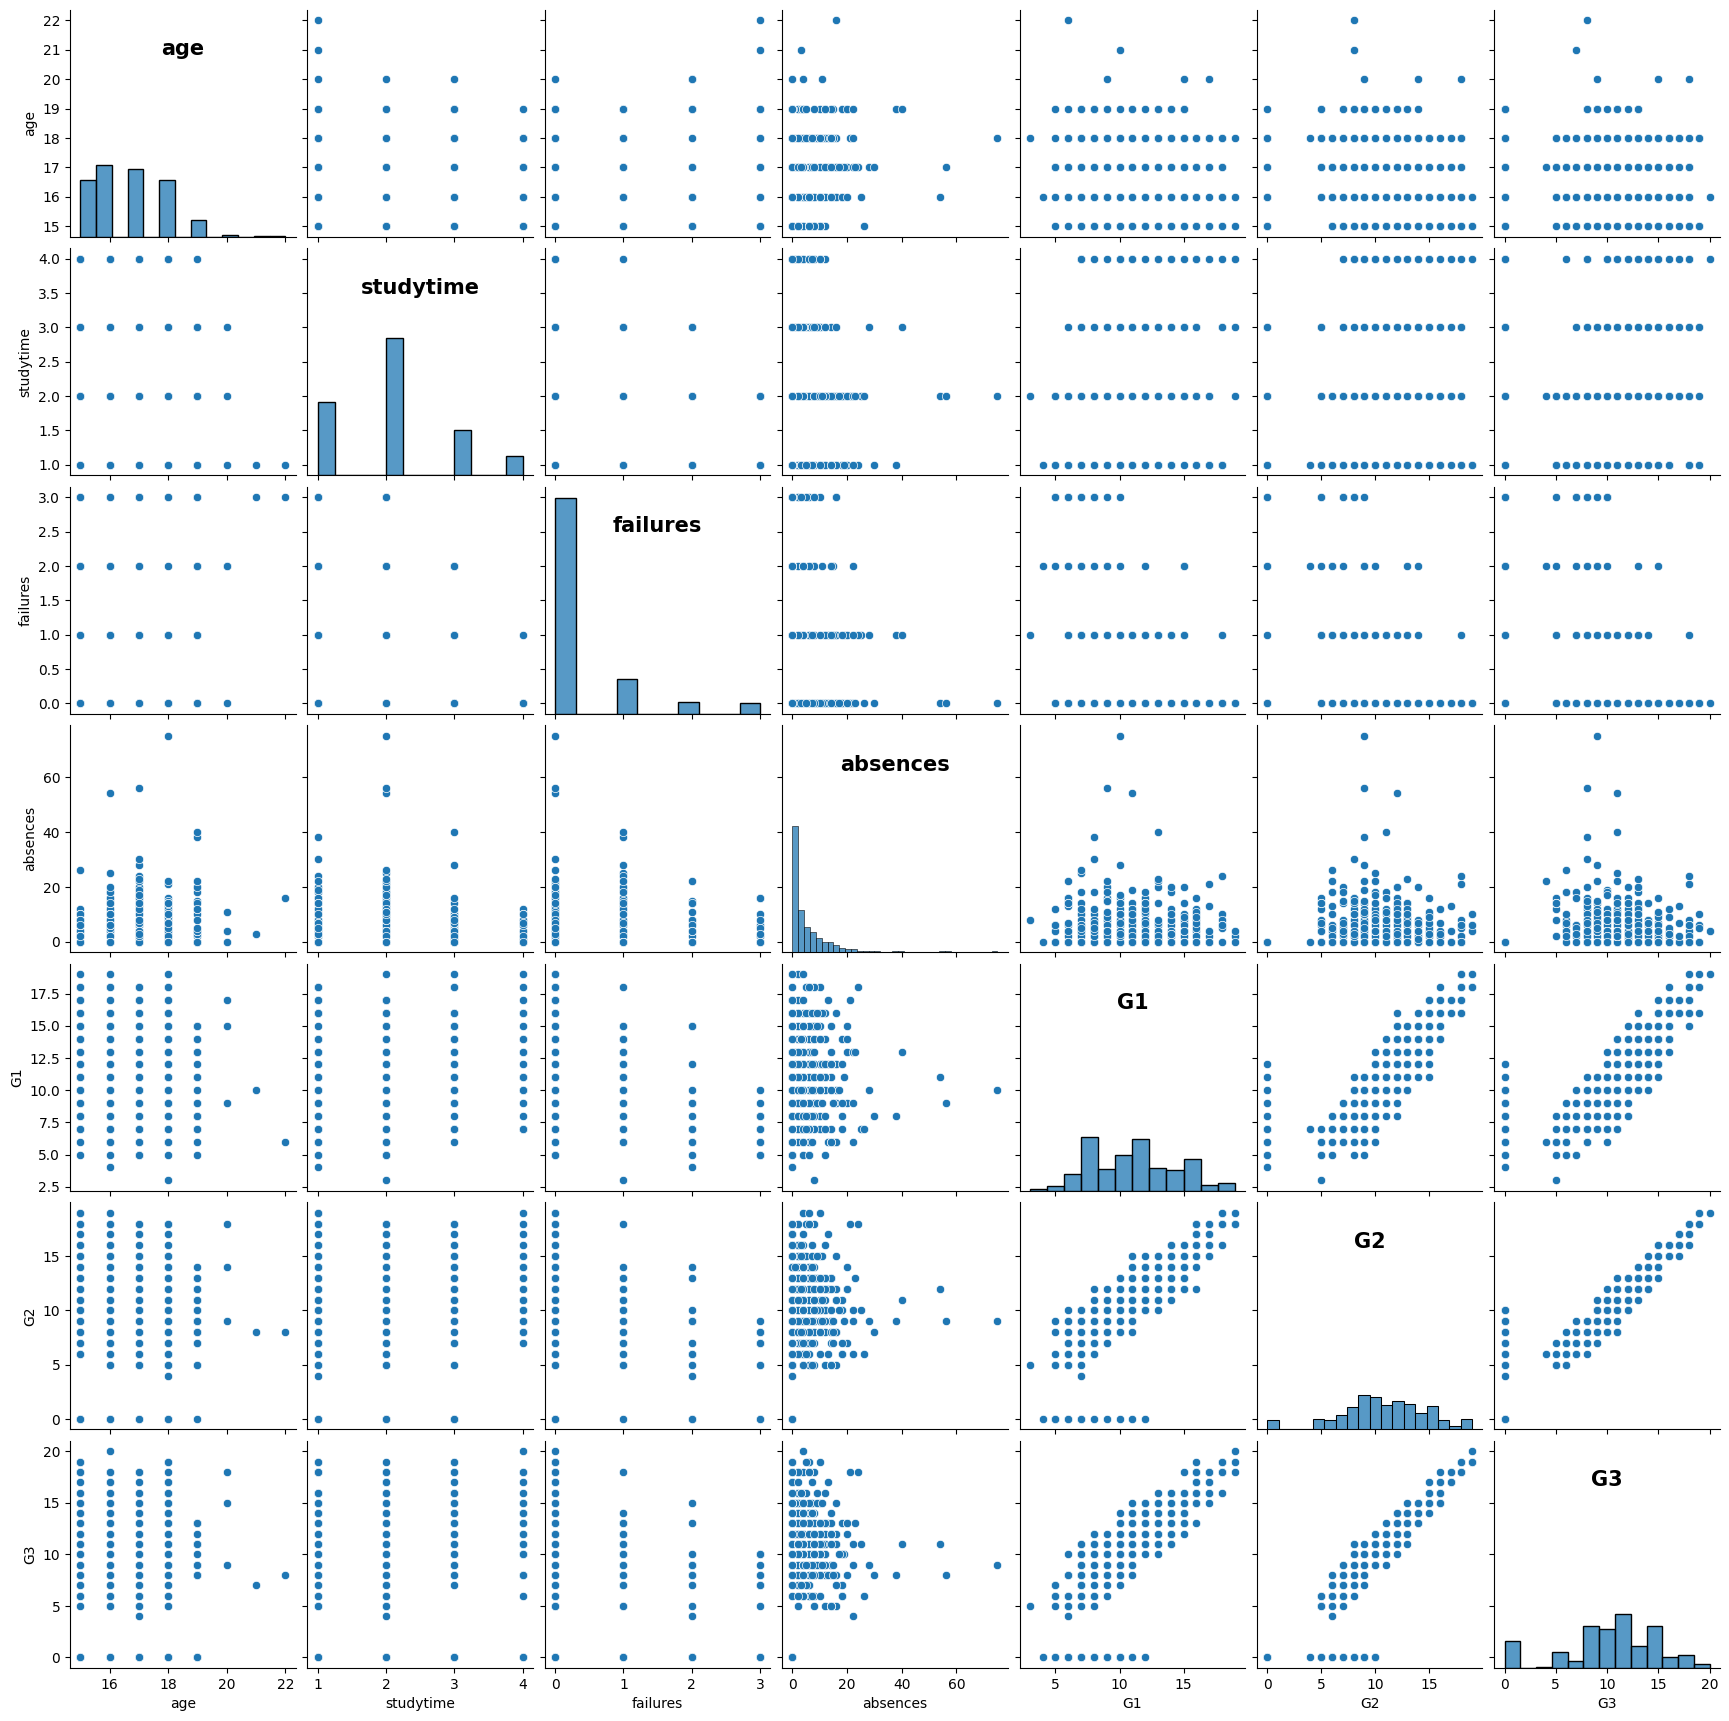

In [8]:
g = sns.pairplot(quant_df, diag_kind='hist')
for i, var in enumerate(quant_df.columns):
    ax = g.axes[i,i]
    ax.text(0.5, 0.8, var, fontsize=15, fontweight='bold', ha='center', transform=ax.transAxes, color='black')
plt.show()

In [9]:
X = df[['studytime',
        'failures',
        'absences',
        'age',
        'G1',
        'G2']]

y = df['G3']
X = sm.add_constant(X)
model = sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     316.8
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          3.93e-146
Time:                        19:21:08   Log-Likelihood:                -810.67
No. Observations:                 395   AIC:                             1635.
Df Residuals:                     388   BIC:                             1663.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1464      1.360      0.843      0.4

In [10]:
print(model.params)

const        1.146428
studytime   -0.167642
failures    -0.220315
absences     0.040764
age         -0.159529
G1           0.165368
G2           0.962341
dtype: float64


In [11]:
X2 = df[['absences',
         'age',
         'G1',
         'G2']]
X2 = sm.add_constant(X2)
reduced_model = sm.OLS(y,X2).fit()
print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     471.9
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          5.79e-148
Time:                        19:21:08   Log-Likelihood:                -812.65
No. Observations:                 395   AIC:                             1635.
Df Residuals:                     390   BIC:                             1655.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0927      1.349      0.810      0.4

In [12]:
X = df[['age',
        'studytime',
        'failures',
        'absences',
        'G1',
        'G2',
        'G3']]

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
pca = PCA()
principal_components = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)

[0.42654731 0.17363704 0.14220739 0.12375487 0.09392773 0.02776576
 0.0121599 ]


In [15]:
variance_df = pd.DataFrame({
'Principal Component': range(1,len(pca.explained_variance_ratio_)+1),
'Explained Variance': pca.explained_variance_ratio_
})

print(variance_df)

   Principal Component  Explained Variance
0                    1            0.426547
1                    2            0.173637
2                    3            0.142207
3                    4            0.123755
4                    5            0.093928
5                    6            0.027766
6                    7            0.012160


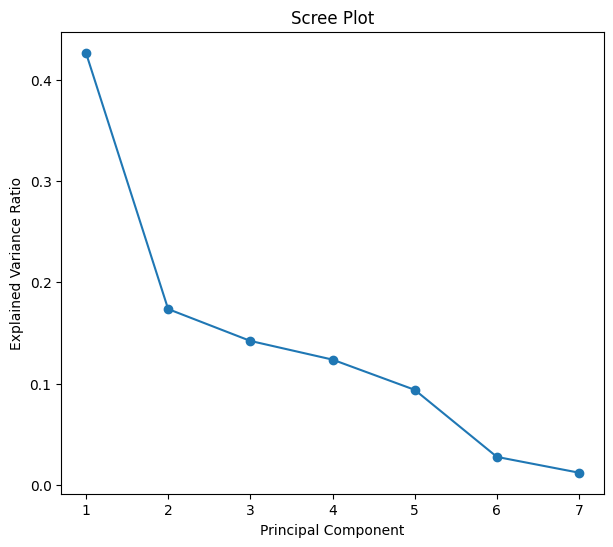

In [16]:
plt.figure(figsize=(7,6))
plt.plot(
    range(1,len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_,
    marker='o'
)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

In [17]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
print(cum_var)

[0.42654731 0.60018435 0.74239174 0.8661466  0.96007434 0.9878401
 1.        ]


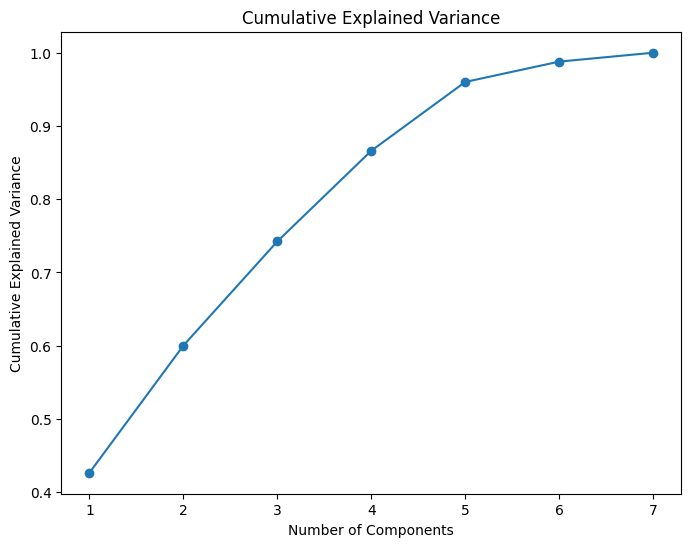

In [18]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1,len(cum_var)+1),
    cum_var,
    marker='o'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.show()

In [19]:
loadings = pd.DataFrame(
pca.components_.T,
columns=[f'PC{i+1}'
for i in range(len(X.columns))],
index=X.columns
)
print(loadings)

                PC1       PC2       PC3       PC4       PC5       PC6  \
age       -0.142367  0.628465  0.374014 -0.397768 -0.524455 -0.107709   
studytime  0.135316 -0.180942  0.910844  0.105003  0.325608 -0.044730   
failures  -0.318894  0.313235 -0.101672 -0.479129  0.747936  0.023983   
absences  -0.034738  0.639216 -0.016787  0.740609  0.188613  0.063224   
G1         0.523355  0.157795  0.002754 -0.172091  0.017032  0.794301   
G2         0.545810  0.129423 -0.073375 -0.140179  0.103922 -0.221678   
G3         0.535455  0.154687 -0.120277 -0.058503  0.113369 -0.549336   

                PC7  
age       -0.001707  
studytime -0.016313  
failures  -0.017448  
absences   0.042889  
G1        -0.200930  
G2         0.774833  
G3        -0.597367  


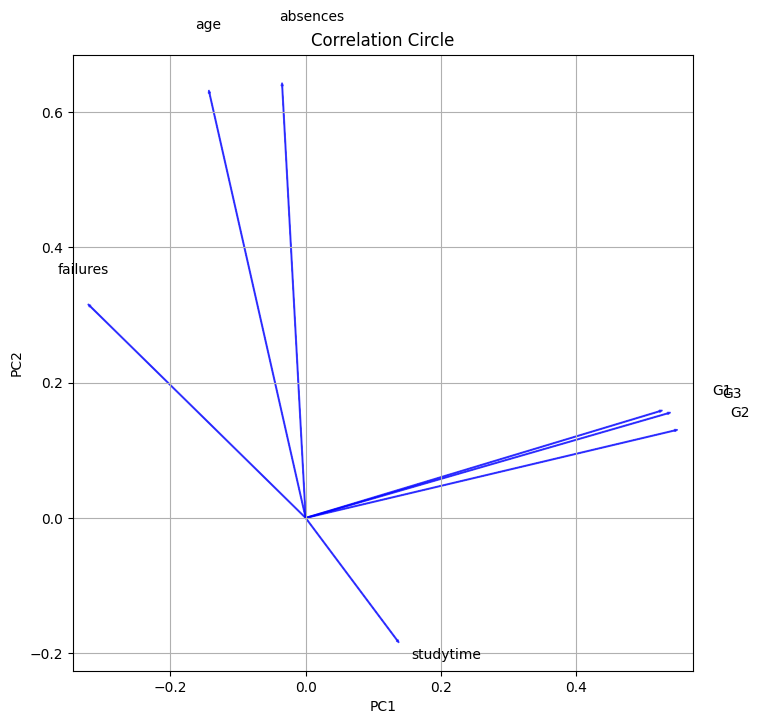

In [20]:
plt.figure(figsize=(8,8))
loadings = pca.components_.T
for i, variable in enumerate(X.columns):
    plt.arrow(
        0,
        0,
        loadings[i,0],
        loadings[i,1],
        color='blue',
        alpha=0.7
    )
    plt.text(
        loadings[i,0]*1.15,
        loadings[i,1]*1.15,
        variable
    )
circle = plt.Circle(
    (0,0),
    1,
    color='red',
    fill=False
)
plt.gca().add_artist(circle)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Correlation Circle')
plt.axis('equal')
plt.grid()
plt.show()

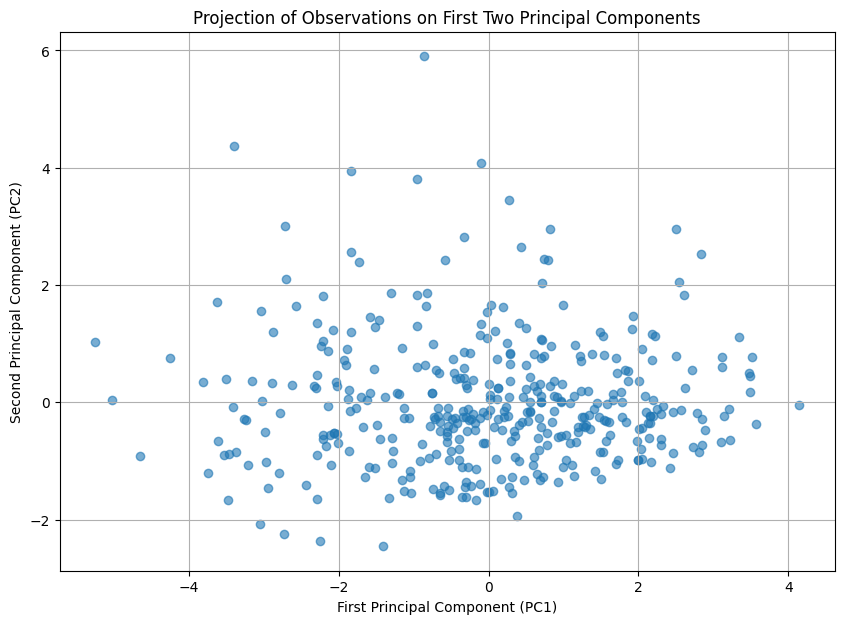

In [21]:
plt.figure(figsize=(10,7))
plt.scatter(
    principal_components[:,0],
    principal_components[:,1],
    alpha=0.6
)
plt.xlabel("First Principal Component (PC1)")
plt.ylabel("Second Principal Component (PC2)")
plt.title("Projection of Observations on First Two Principal Components")
plt.grid()
plt.show()

In [22]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

In [23]:
components = pca.fit_transform(X_scaled)

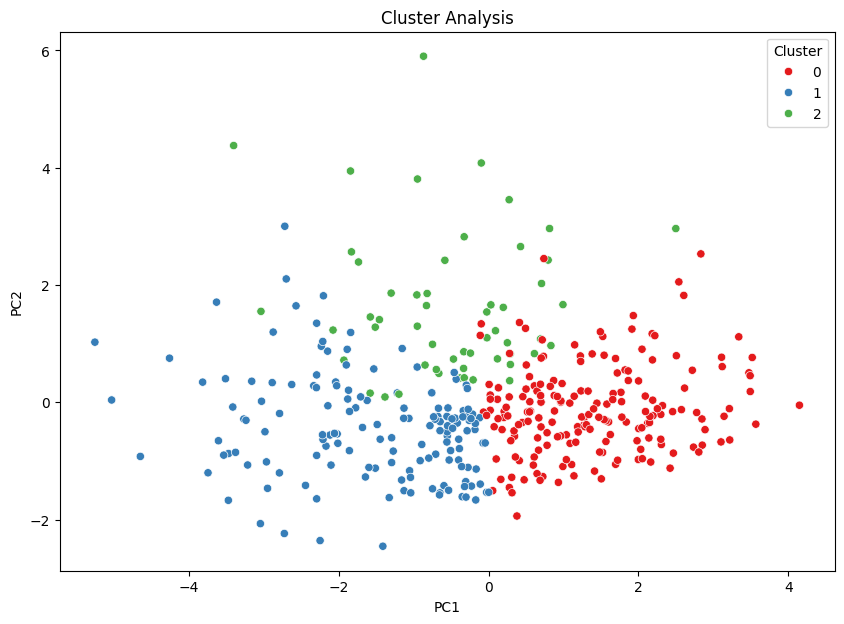

In [24]:
plt.figure(figsize=(10,7))
sns.scatterplot(
x=components[:,0],
y=components[:,1],
hue=df['Cluster'],
palette='Set1'
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cluster Analysis")
plt.show()

In [25]:
df.groupby('Cluster')[

['studytime',
 'absences',
 'failures',
 'G1',
 'G2',
 'G3']
].mean()

,studytime,absences,failures,G1,G2,G3
Cluster,,,,,,
0,2.194737,3.605263,0.057895,13.431579,13.547368,13.705263
1,1.927152,3.377483,0.602649,7.867550,7.417219,6.417219
2,1.777778,19.629630,0.555556,10.537037,9.962963,10.018519
